<a href="https://colab.research.google.com/github/ashishsingh752/SolarEnergyPredictionUsingML/blob/main/first.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Solar Energy

Root Mean Squared Error: 2.083180550515482e-05


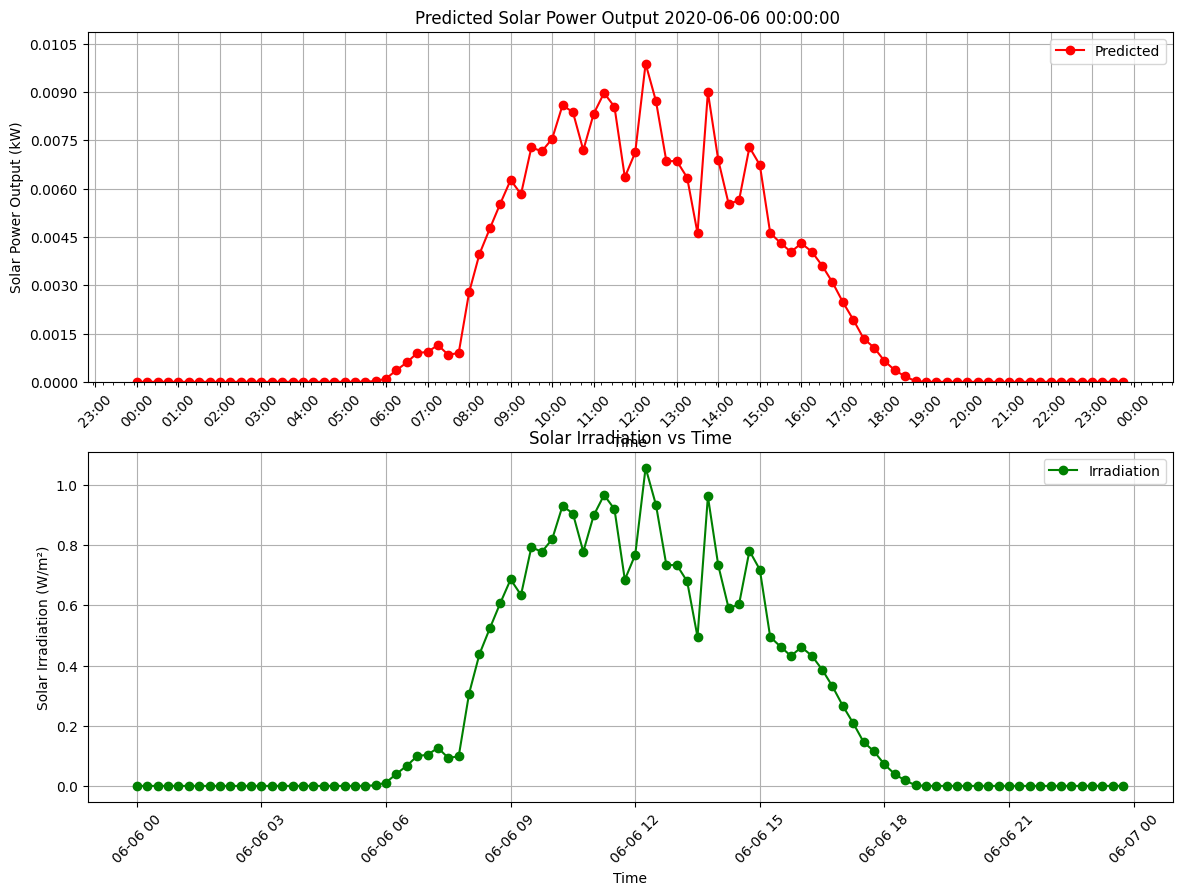

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Import for date formatting
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load the dataset
data = pd.read_csv('/content/solar_data.csv')

# Feature engineering: Adding hour of the day as a feature
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'], format='%d-%m-%Y %H:%M')
data['HOUR'] = data['DATE_TIME'].dt.hour

# Constants
P_STC = 1.0  # Standard Test Condition power per unit area (kW/m^2)
D_f = 0.9    # Derating factor
G_STC = 1000 # Standard Test Condition irradiation (W/m^2)
T_STC = 25   # Standard Test Condition temperature (°C)
C_t = 0.0045 # Temperature coefficient
NOCT = 45    # Nominal Operating Cell Temperature (°C)

# Define the PV panel rating (in kW, adjust this based on your PV panel)
PV_PANEL_RATING = 10  # Example: 10 kW

# Calculate T_c (Cell Temperature)
data['T_c'] = data['AMBIENT_TEMPERATURE'] + 0.8 * (NOCT - 20) * data['IRRADIATION'] / G_STC

# Calculate P_actual (Actual Power Output) considering PV panel rating
data['P_actual'] = PV_PANEL_RATING * D_f * (data['IRRADIATION'] / G_STC) * (1 + C_t * (data['T_c'] - T_STC))

# Define features and target
X = data[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR']]
y = data['P_actual']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a machine learning model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# Filter data for a full 24-hour period from 00:00 to 00:00 of the next day
start_time = pd.to_datetime('06-06-2020 00:00', format='%d-%m-%Y %H:%M')
end_time = start_time + pd.Timedelta(days=1)

day_data = data[(data['DATE_TIME'] >= start_time) & (data['DATE_TIME'] < end_time)]

# Make predictions for that day
day_X = day_data[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR']]
day_y_pred = model.predict(day_X)

# Plot the actual vs predicted values along with irradiation vs time
plt.figure(figsize=(14, 10))

# Subplot 2: Solar Irradiation vs Time
plt.subplot(2, 1, 2)
plt.plot(day_data['DATE_TIME'], day_data['IRRADIATION'], marker='o', label='Irradiation', color='green')
plt.xlabel('Time')
plt.ylabel('Solar Irradiation (W/m²)')
plt.title('Solar Irradiation vs Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Subplot 1: Actual vs Predicted Solar Power Output
plt.subplot(2, 1, 1)
# plt.plot(day_data['DATE_TIME'], day_data['P_actual'], marker='o', label='Actual', color='blue')
plt.plot(day_data['DATE_TIME'], day_y_pred, marker='o', label='Predicted', color='red', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Solar Power Output (kW)')
plt.title(f"Predicted Solar Power Output {start_time} " )
plt.legend()
plt.xticks(rotation=45)
plt.ylim([0, max(day_data['P_actual'].max(), day_y_pred.max()) * 1.1])  # Adjust Y-axis scale
plt.grid()

# Set x-axis to show time every 15 minutes
plt.gca().xaxis.set_major_locator(mdates.HourLocator())  # Major ticks every hour
plt.gca().xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))  # Minor ticks every 15 minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format the ticks as HH:MM

# Adding more grid lines for precise view
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(10))  # Divide Y-axis into more blocks


# Set x-axis to show time every 15 minutes
plt.gca().xaxis.set_major_locator(mdates.HourLocator())  # Major ticks every hour
plt.gca().xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))  # Minor ticks every 15 minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format the ticks as HH:MM

# Adding more grid lines for precise view
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(10))  # Divide Y-axis into more blocks

# Improve spacing between subplots
# plt.tight_layout()

# Show the plot
plt.show()


## Wind energy

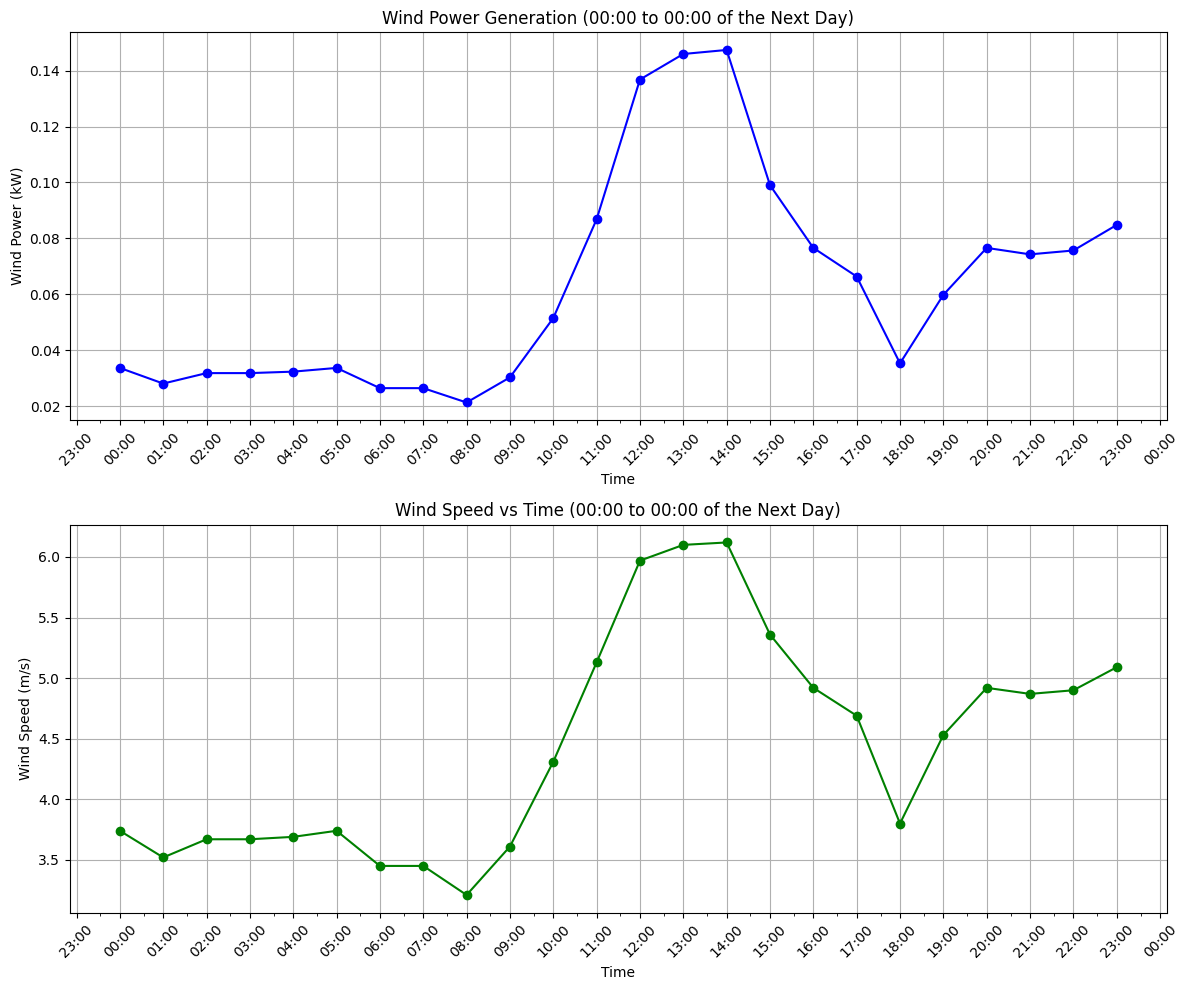

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the dataset
data = pd.read_csv('/content/windData.csv')

# Convert Time to datetime object
data['Time'] = pd.to_datetime(data['Time'], format='%d-%m-%Y %H:%M')

# Constants
rho = 1.225  # Air density in kg/m³
A = 3        # Swept area in m² (example value)
eta = 0.35   # Efficiency of the turbine
P_rated = 500  # Rated power of the turbine in kW (example value)

# Calculate theoretical wind power (in kW) using wind speed at 10m height
data['Theoretical_Power_kW'] = 0.5 * rho * A * (data['windspeed_10m'] ** 3) / 1000

# Calculate actual power output considering efficiency and turbine rating
data['Actual_Power_kW'] = np.minimum(data['Theoretical_Power_kW'] * eta, P_rated)

# Filter data for the 24-hour period (00:00 to 00:00 of the next day)
start_time = pd.Timestamp('02-01-2017 00:00')
end_time = start_time + pd.Timedelta(days=1)
filtered_data = data[(data['Time'] >= start_time) & (data['Time'] < end_time)]

# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1: Wind Power Generation
ax1[0].plot(filtered_data['Time'], filtered_data['Actual_Power_kW'], marker='o', linestyle='-', color='blue')
ax1[0].set_xlabel('Time')
ax1[0].set_ylabel('Wind Power (kW)')
ax1[0].set_title('Wind Power Generation (00:00 to 00:00 of the Next Day)')
ax1[0].xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1[0].xaxis.set_minor_locator(mdates.MinuteLocator(interval=60))
ax1[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1[0].tick_params(axis='x', rotation=45)
ax1[0].grid(True)

# Subplot 2: Wind Speed vs Time
ax1[1].plot(filtered_data['Time'], filtered_data['windspeed_10m'], marker='o', linestyle='-', color='green')
ax1[1].set_xlabel('Time')
ax1[1].set_ylabel('Wind Speed (m/s)')
ax1[1].set_title('Wind Speed vs Time (00:00 to 00:00 of the Next Day)')
ax1[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1[1].xaxis.set_minor_locator(mdates.MinuteLocator(interval=60))
ax1[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1[1].tick_params(axis='x', rotation=45)
ax1[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()
# data.head()